In [10]:
# ══════════════════════════════════════════════════════
# MASTER SETUP CELL — run this first every time
# ══════════════════════════════════════════════════════

# Install libraries
!pip install plotly pycountry -q

# Core imports
import requests
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import time
import pycountry
from google.colab import files

print(" All libraries loaded!")
print("\nNew libraries this project:")
print("  requests  → fetch data from WHO API")
print("  sqlite3   → create and query SQL database")
print("  plotly    → interactive charts + world map")
print("  pycountry → convert country codes to names")

 All libraries loaded!

New libraries this project:
  requests  → fetch data from WHO API
  sqlite3   → create and query SQL database
  plotly    → interactive charts + world map
  pycountry → convert country codes to names


In [11]:
# ── Phase 1: Fetch data from WHO API ─────────────────────────────

# We'll fetch 5 key health indicators
# Each indicator has a code — found from WHO GHO API docs

INDICATORS = {
    'MALARIA_DEATHS'    : 'Malaria Deaths',
    'MDG_0000000020'    : 'Tuberculosis Incidence',
    'NCD_GLUC_04'       : 'Diabetes Prevalence',
    'NCDMORT3070'       : 'NCD Mortality (30-70 age)',
    'WHOSIS_000001'     : 'Life Expectancy',
}

BASE_URL = "https://ghoapi.azureedge.net/api/"

def fetch_indicator(code, name):
    """Fetch all data for one WHO indicator"""
    print(f"Fetching {name}...", end=" ")

    url = f"{BASE_URL}{code}"
    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        print(f" Failed (status {response.status_code})")
        return None

    data = response.json()
    records = data.get('value', [])

    if not records:
        print(" No data")
        return None

    df = pd.DataFrame(records)
    df['indicator_code'] = code
    df['indicator_name'] = name
    print(f"{len(df):,} records")
    return df

# Fetch all indicators
all_data = []
for code, name in INDICATORS.items():
    df = fetch_indicator(code, name)
    if df is not None:
        all_data.append(df)
    time.sleep(0.5)  # be polite to the API

# Combine all into one dataframe
raw_df = pd.concat(all_data, ignore_index=True)
print(f"\nTotal records fetched: {len(raw_df):,}")
print(f"\nColumns available:")
print(list(raw_df.columns))
print(f"\nSample data:")
raw_df.head(3)

Fetching Malaria Deaths...  Failed (status 404)
Fetching Tuberculosis Incidence... 5,177 records
Fetching Diabetes Prevalence... 21,630 records
Fetching NCD Mortality (30-70 age)... 12,936 records
Fetching Life Expectancy... 12,936 records

Total records fetched: 52,679

Columns available:
['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim', 'ParentLocationCode', 'TimeDimType', 'ParentLocation', 'Dim1Type', 'Dim1', 'TimeDim', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3', 'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low', 'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin', 'TimeDimensionEnd', 'indicator_code', 'indicator_name']

Sample data:


,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,Dim1,TimeDim,...,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd,indicator_code,indicator_name
0,5213335,MDG_0000000020,COUNTRY,TJK,EUR,YEAR,Europe,None,None,2009,...,180.0,147.0,217.0,None,2025-11-11T15:08:09.963+01:00,2009,2009-01-01T00:00:00+01:00,2009-12-31T00:00:00+01:00,MDG_0000000020,Tuberculosis Incidence
1,5218765,MDG_0000000020,COUNTRY,MHL,WPR,YEAR,Western Pacific,None,None,2016,...,649.0,528.0,782.0,None,2025-11-11T15:08:09.963+01:00,2016,2016-01-01T00:00:00+01:00,2016-12-31T00:00:00+01:00,MDG_0000000020,Tuberculosis Incidence
2,5219083,MDG_0000000020,COUNTRY,KIR,WPR,YEAR,Western Pacific,None,None,2014,...,870.0,708.0,1050.0,None,2025-11-11T15:08:09.963+01:00,2014,2014-01-01T00:00:00+01:00,2014-12-31T00:00:00+01:00,MDG_0000000020,Tuberculosis Incidence


In [12]:
# ── Phase 2: Clean + Load into SQLite ────────────────────────────

# Step 1: Keep only useful columns
clean_df = raw_df[[
    'SpatialDim', 'ParentLocation', 'TimeDim',
    'NumericValue', 'indicator_code', 'indicator_name'
]].copy()

# Rename for clarity
clean_df.columns = [
    'country_code', 'region', 'year',
    'value', 'indicator_code', 'indicator_name'
]

# Step 2: Drop rows with no numeric value
clean_df = clean_df.dropna(subset=['value', 'country_code', 'year'])

# Step 3: Keep only COUNTRY level rows (remove global/regional aggregates)
clean_df = clean_df[clean_df['country_code'].str.len() == 3]

# Step 4: Convert year to int
clean_df['year'] = clean_df['year'].astype(int)

print(f"   Clean records: {len(clean_df):,}")
print(f"   Countries found: {clean_df['country_code'].nunique()}")
print(f"   Year range: {clean_df['year'].min()} – {clean_df['year'].max()}")
print(f"   Indicators: {clean_df['indicator_name'].unique()}")

# Step 5: Load into SQLite
conn = sqlite3.connect('who_health.db')

clean_df.to_sql('health_data', conn, if_exists='replace', index=False)

print(f"\n Database created: who_health.db")
print(f"   Table: health_data")
print(f"   Rows loaded: {len(clean_df):,}")

   Clean records: 50,582
   Countries found: 203
   Year range: 1980 – 2024
   Indicators: ['Tuberculosis Incidence' 'Diabetes Prevalence'
 'NCD Mortality (30-70 age)' 'Life Expectancy']

 Database created: who_health.db
   Table: health_data
   Rows loaded: 50,582


In [13]:
# ── Phase 3: SQL Queries (Fixed) ─────────────────────────────────

def run_query(sql, description):
    print(f"\n{'═'*55}")
    print(f"Q: {description}")
    print(f"{'═'*55}")
    df = pd.read_sql_query(sql, conn)
    print(df.to_string(index=False))
    return df

# ── Query 1: Top 10 Life Expectancy (no duplicates) ──────────────
q1 = run_query("""
    SELECT country_code, region, ROUND(value, 1) as life_expectancy
    FROM health_data
    WHERE indicator_name = 'Life Expectancy'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Life Expectancy')
    GROUP BY country_code
    ORDER BY life_expectancy DESC
    LIMIT 10
""", "Top 10 countries by Life Expectancy (latest year)")

# ── Query 2: Bottom 10 (no duplicates) ───────────────────────────
q2 = run_query("""
    SELECT country_code, region, ROUND(value, 1) as life_expectancy
    FROM health_data
    WHERE indicator_name = 'Life Expectancy'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Life Expectancy')
    GROUP BY country_code
    ORDER BY life_expectancy ASC
    LIMIT 10
""", "Bottom 10 countries by Life Expectancy (latest year)")

# ── Query 3: India vs Global Average (fixed — no JOIN) ────────────
q3 = run_query("""
    SELECT
        h.indicator_name,
        ROUND(MAX(CASE WHEN h.country_code = 'IND'
                       THEN h.value END), 2)  AS india_value,
        ROUND(AVG(h.value), 2)                AS global_avg,
        ROUND(MAX(CASE WHEN h.country_code = 'IND'
                       THEN h.value END)
              - AVG(h.value), 2)              AS difference
    FROM health_data h
    WHERE h.year = 2021
    GROUP BY h.indicator_name
""", "India vs Global Average (2021)")

# ── Query 4: Diabetes by Region (use latest available year) ───────
q4 = run_query("""
    SELECT region,
           ROUND(AVG(value), 2) AS avg_diabetes_prevalence,
           COUNT(DISTINCT country_code) AS countries
    FROM health_data
    WHERE indicator_name = 'Diabetes Prevalence'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Diabetes Prevalence')
    GROUP BY region
    ORDER BY avg_diabetes_prevalence DESC
""", "Average Diabetes Prevalence by Region (latest year)")

# ── Query 5: TB Incidence — Top 10 worst countries ────────────────
q5 = run_query("""
    SELECT country_code, region, ROUND(value, 1) as tb_incidence
    FROM health_data
    WHERE indicator_name = 'Tuberculosis Incidence'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Tuberculosis Incidence')
    GROUP BY country_code
    ORDER BY tb_incidence DESC
    LIMIT 10
""", "Top 10 countries by TB Incidence (latest year)")


═══════════════════════════════════════════════════════
Q: Top 10 countries by Life Expectancy (latest year)
═══════════════════════════════════════════════════════
country_code          region  life_expectancy
         SGP Western Pacific             86.3
         AUS Western Pacific             84.9
         LUX          Europe             84.8
         JPN Western Pacific             84.5
         ITA          Europe             84.3
         FIN          Europe             84.1
         NZL Western Pacific             84.0
         CYP          Europe             84.0
         ISL          Europe             83.9
         KOR Western Pacific             83.8

═══════════════════════════════════════════════════════
Q: Bottom 10 countries by Life Expectancy (latest year)
═══════════════════════════════════════════════════════
country_code                region  life_expectancy
         LSO                Africa             48.7
         CAF                Africa             49.6
   

In [15]:
# ── Phase 4: Visualisations ───────────────────────────────────────

import plotly.io as pio
pio.renderers.default = "colab"

# ── Chart 1: India vs Global Average (Bar Chart) ─────────────────
q3_plot = pd.read_sql_query("""
    SELECT
        indicator_name,
        ROUND(MAX(CASE WHEN country_code = 'IND' THEN value END), 2) AS india_value,
        ROUND(AVG(value), 2) AS global_avg
    FROM health_data
    WHERE year = 2021
    GROUP BY indicator_name
""", conn)

# Melt for grouped bar chart
q3_melted = q3_plot.melt(
    id_vars='indicator_name',
    value_vars=['india_value', 'global_avg'],
    var_name='Category',
    value_name='Value'
)
q3_melted['Category'] = q3_melted['Category'].map({
    'india_value': 'India',
    'global_avg': 'Global Average'
})

fig1 = px.bar(
    q3_melted,
    x='indicator_name',
    y='Value',
    color='Category',
    barmode='group',
    title='India vs Global Average — Key Health Indicators (2021)',
    color_discrete_map={'India': '#FF6B35', 'Global Average': '#4A90D9'},
    labels={'indicator_name': 'Indicator', 'Value': 'Value'}
)
fig1.update_layout(xaxis_tickangle=-15)
fig1.show()

# ── Chart 2: Life Expectancy World Map ───────────────────────────
map_df = pd.read_sql_query("""
    SELECT country_code, region, ROUND(AVG(value), 1) as life_expectancy
    FROM health_data
    WHERE indicator_name = 'Life Expectancy'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Life Expectancy')
    GROUP BY country_code
""", conn)

fig2 = px.choropleth(
    map_df,
    locations='country_code',
    color='life_expectancy',
    hover_name='country_code',
    hover_data={'region': True, 'life_expectancy': True},
    color_continuous_scale='RdYlGn',
    title='Life Expectancy by Country (Latest Year)',
    labels={'life_expectancy': 'Life Expectancy (years)'}
)
fig2.show()

# ── Chart 3: India Life Expectancy Trend over time ───────────────
india_trend = pd.read_sql_query("""
    SELECT year, indicator_name, ROUND(value, 2) as value
    FROM health_data
    WHERE country_code = 'IND'
      AND year >= 2000
    ORDER BY indicator_name, year
""", conn)

fig3 = px.line(
    india_trend,
    x='year',
    y='value',
    color='indicator_name',
    title="India's Health Trends (2000–Present)",
    labels={'year': 'Year', 'value': 'Value', 'indicator_name': 'Indicator'},
    markers=True
)
fig3.show()

# ── Chart 4: Diabetes Prevalence by Region ───────────────────────
diabetes_region = pd.read_sql_query("""
    SELECT region, ROUND(AVG(value), 2) AS avg_diabetes
    FROM health_data
    WHERE indicator_name = 'Diabetes Prevalence'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Diabetes Prevalence')
      AND region IS NOT NULL
    GROUP BY region
    ORDER BY avg_diabetes DESC
""", conn)

fig4 = px.bar(
    diabetes_region,
    x='region',
    y='avg_diabetes',
    title='Average Diabetes Prevalence by WHO Region (Latest Year)',
    color='avg_diabetes',
    color_continuous_scale='Reds',
    labels={'region': 'WHO Region', 'avg_diabetes': 'Avg Prevalence (%)'}
)
fig4.show()

print(" All 4 charts generated!")

✅ All 4 charts generated!


In [16]:
# ── Save charts as HTML files ─────────────────────────────────────

fig1.write_html("chart1_india_vs_global.html")
fig2.write_html("chart2_world_map.html")
fig3.write_html("chart3_india_trend.html")
fig4.write_html("chart4_diabetes_region.html")

print(" Charts saved!")

# Download all
from google.colab import files
files.download("chart1_india_vs_global.html")
files.download("chart2_world_map.html")
files.download("chart3_india_trend.html")
files.download("chart4_diabetes_region.html")

✅ Charts saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
# ── Chart 2 Fix: World Map ────────────────────────────────────────

map_df = pd.read_sql_query("""
    SELECT country_code, region, ROUND(AVG(value), 1) as life_expectancy
    FROM health_data
    WHERE indicator_name = 'Life Expectancy'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Life Expectancy')
    GROUP BY country_code
""", conn)

fig2 = px.choropleth(
    map_df,
    locations='country_code',
    locationmode='ISO-3',          # ← this was missing
    color='life_expectancy',
    hover_name='country_code',
    hover_data={'region': True, 'life_expectancy': True},
    color_continuous_scale='RdYlGn',
    title='Life Expectancy by Country (Latest Year)',
    labels={'life_expectancy': 'Life Expectancy (years)'}
)
fig2.update_layout(
    geo=dict(showframe=False, showcoastlines=True)
)
fig2.write_html("chart2_world_map_fixed.html")

from google.colab import files
files.download("chart2_world_map_fixed.html")

print(" World map downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 World map downloaded!


Valid countries: 185


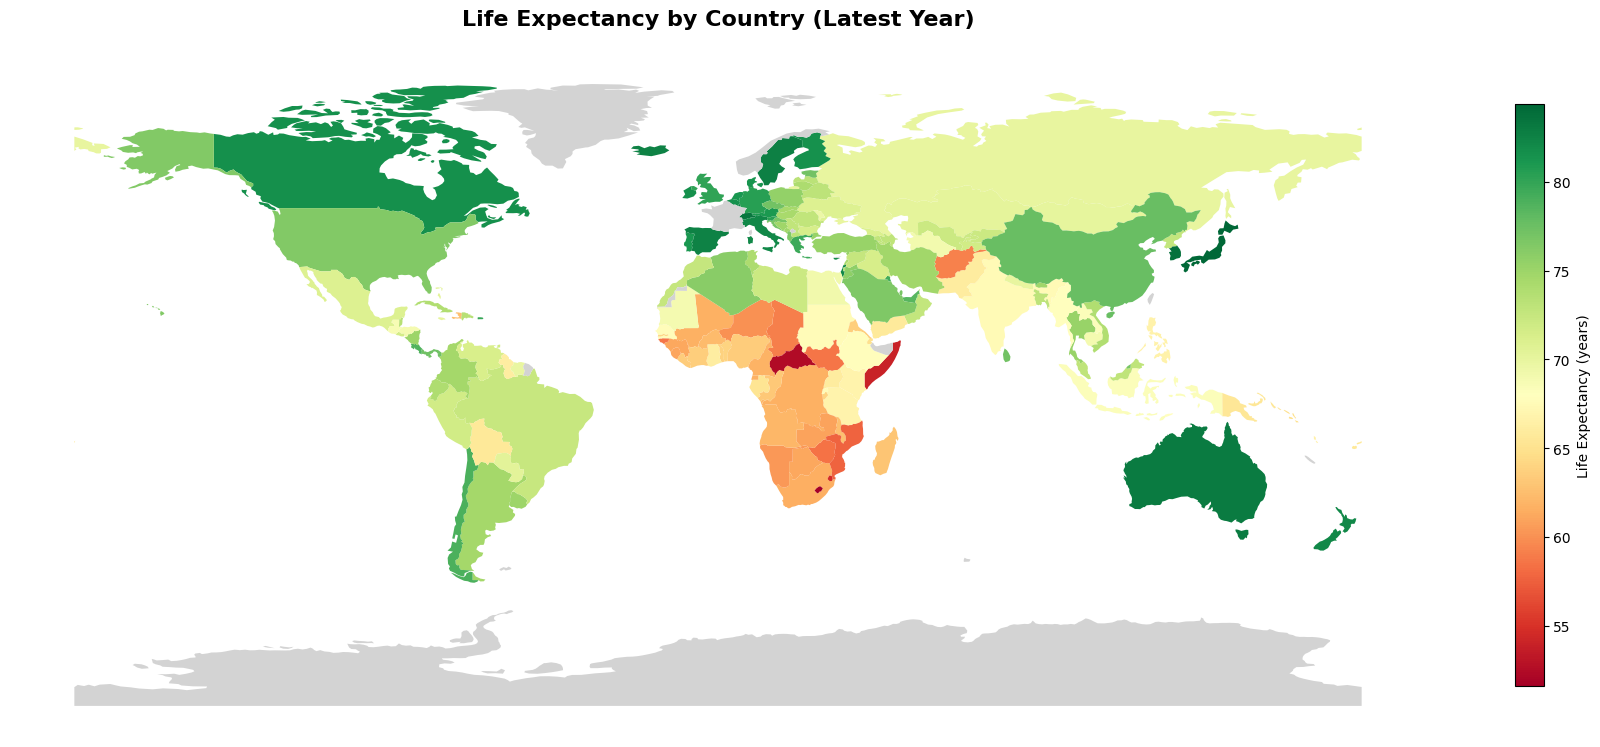

Done!


In [23]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Recreate valid_countries from database
map_df = pd.read_sql_query("""
    SELECT country_code, region, ROUND(AVG(value), 1) as life_expectancy
    FROM health_data
    WHERE indicator_name = 'Life Expectancy'
      AND year = (SELECT MAX(year) FROM health_data
                  WHERE indicator_name = 'Life Expectancy')
    GROUP BY country_code
""", conn)

valid_countries = map_df[
    map_df['region'].notna() &
    (map_df['country_code'].str.len() == 3) &
    (~map_df['country_code'].isin([
        'AFR','AMR','EMR','EUR','SEAR','WPR',
        'GLB','LMC','UMC','HIC','LIC','WLD'
    ]))
]

print(f"✅ Valid countries: {len(valid_countries)}")

# Step 2: Load shapefile
url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# Step 3: Merge + plot
world_merged = world.merge(
    valid_countries[['country_code', 'life_expectancy']],
    left_on='ISO_A3',
    right_on='country_code',
    how='left'
)

fig, ax = plt.subplots(1, 1, figsize=(18, 10))
world_merged.plot(
    column='life_expectancy',
    ax=ax,
    legend=True,
    cmap='RdYlGn',
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    legend_kwds={'label': 'Life Expectancy (years)', 'shrink': 0.6}
)
ax.set_title('Life Expectancy by Country (Latest Year)',
             fontsize=16, fontweight='bold', pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('world_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

In [31]:
from google.colab import files

# Download notebook
files.download('/content/who_health.db')
files.download('/content/who_health_data.csv')
files.download('/content/who_dashboard.py')

print("All files downloading!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloading!


In [30]:
# ── Export data for Looker Studio ────────────────────────────────

import pandas as pd
import sqlite3

conn = sqlite3.connect('/content/who_health.db')

df = pd.read_sql_query("SELECT * FROM health_data", conn)

# Filter out regional aggregates
df_clean = df[
    df['region'].notna() &
    (df['country_code'].str.len() == 3) &
    (~df['country_code'].isin([
        'AFR','AMR','EMR','EUR','SEAR','WPR',
        'GLB','LMC','UMC','HIC','LIC','WLD'
    ]))
]

df_clean.to_csv('who_health_data.csv', index=False)
print(f"Exported {len(df_clean):,} rows")
print(f"Columns: {list(df_clean.columns)}")

from google.colab import files
files.download('who_health_data.csv')

Exported 49,222 rows
Columns: ['country_code', 'region', 'year', 'value', 'indicator_code', 'indicator_name']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>